In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from h_test_IQM.pipeline.multiple import run_multiple_pipelines_diff
from h_test_IQM.pipeline.main import plot_hist, samples_to_pdf

In [3]:
# parameters for each test to set up
run1 = {'dataset_target': 'CIFAR_10',
        'dataset_test': 'CIFAR_10',
        'target_labels': 'all', 
        'test_labels': 'all',
        'transform_target':'gaussian_noise',
        'transform_test':'gaussian_noise',
        'dataset_proportion_target': 0.1,
        'dataset_proportion_test': 0.1,
        'test': 'KL',
        'dev': False,   # If True, the code will run on very small data size
        'runs': 100,
        }

# things to change for the test against
run2 = run1.copy()
run2['dataset_target'] = 'UNIFORM'
run2['dataset_test'] = 'UNIFORM'

In [4]:
# run the tests for each configuration
test1, test2 = run_multiple_pipelines_diff([run1, run2])

CIFAR_10 - CIFAR_10:   0%|          | 0/100 [00:00<?, ?it/s]

UNIFORM - UNIFORM: 100%|██████████| 100/100 [09:46<00:00,  5.86s/it]


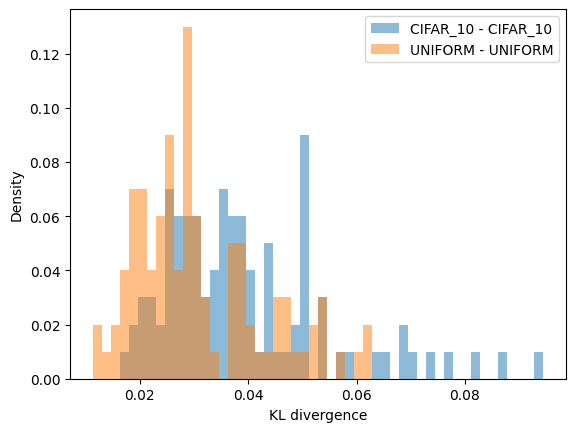

In [5]:
# plot the results (difference of differneces)
test1 = np.array(test1)
test2 = np.array(test2)
dist1, dist2, all_bins, one_bins = samples_to_pdf(
    test2, test1, num_bins=50)
plot_hist(dist1, all_bins, name=run1['name'])
plot_hist(dist2, one_bins, name=run2['name'])
plt.xlabel('KL divergence')
plt.ylabel('Density')
plt.legend()
plt.show()